### TAREFA 1 – SEGMENTAÇÃO

In [7]:
import cv2 as cv
import numpy as np
import time

# Configurações
output_filename = 'tarefa1.mp4'
duration = 3  # segundos
fps = 20
frame_width = 640
frame_height = 480

# Inicializa webcam
cap = cv.VideoCapture(0)
cap.set(cv.CAP_PROP_FRAME_WIDTH, frame_width)
cap.set(cv.CAP_PROP_FRAME_HEIGHT, frame_height)

# Define codec e objeto para gravar vídeo
fourcc = cv.VideoWriter_fourcc(*'mp4v')
out = cv.VideoWriter(output_filename, fourcc, fps, (frame_width, frame_height))

start_time = time.time()

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Segmentação de pele em HSV
    img_hsv = cv.cvtColor(frame, cv.COLOR_BGR2HSV)
    lower = np.array([0, 30, 60], dtype=np.uint8)
    upper = np.array([20, 150, 255], dtype=np.uint8)
    mask = cv.inRange(img_hsv, lower, upper)

    result = np.zeros_like(frame)
    result[mask > 0] = frame[mask > 0]

    # Grava frame no arquivo de vídeo
    out.write(result)

    # Mostra em tempo real
    cv.imshow('Gravando - Somente Pele', result)

    if cv.waitKey(1) & 0xFF == ord('q'):
        break
    if time.time() - start_time > duration:
        break

# Libera recursos
cap.release()
out.release()
cv.destroyAllWindows()


### TAREFA 2 – OPERADORES MORFOLÓGICOS

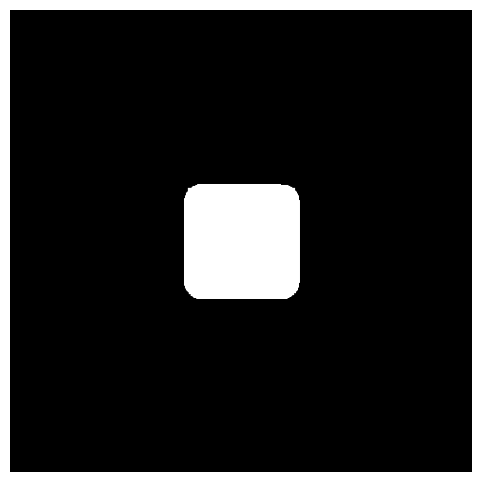

In [2]:
import cv2
import matplotlib.pyplot as plt

# Carrega a imagem em escala de cinza
image = cv2.imread('imA.tif', cv2.IMREAD_GRAYSCALE)

# Define o elemento estruturante (ajuste o tamanho conforme necessário)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (50, 50))

# Aplica a erosão para manter apenas o quadrado central
eroded = cv2.erode(image, kernel, iterations=1)

# Exibe a imagem resultante no próprio notebook
plt.figure(figsize=(6,6))
plt.imshow(eroded, cmap='gray')
plt.axis('off')  # Remove os eixos
plt.show()

Para manter apenas o quadrado central da imagem, o mais adequado é aplicar uma erosão, que remove pixels das bordas, encolhendo objetos. Isso faz com que apenas a parte mais "interna" (como o quadrado central) permaneça.

### TAREFA 3 – OPERADORES MORFOLÓGICOS

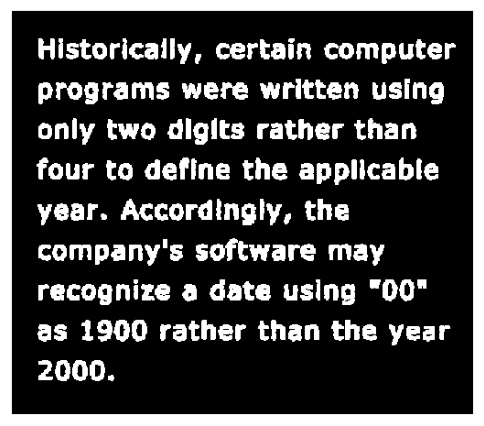

In [1]:
import cv2
import matplotlib.pyplot as plt

# Carrega a imagem em escala de cinza
image = cv2.imread('imB.tif', cv2.IMREAD_GRAYSCALE)

# Define o elemento estruturante (ajuste o tamanho conforme necessário)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

# Aplica a dilatação para melhorar a conectividade
dilated = cv2.dilate(image, kernel, iterations=1)

# Exibe a imagem resultante no próprio notebook
plt.figure(figsize=(6,6))
plt.imshow(dilated, cmap='gray')
plt.axis('off')  # Remove os eixos
plt.show()


Para melhorar a conectividade/qualidade dos caracteres segmentados, a melhor função seria uma operação de dilatação. A dilatação ajuda a aumentar as áreas de objetos, preenchendo buracos e conectando regiões segmentadas, sem alterar muito o tamanho global dos objetos.

